# Employee Attrition — EDA & Preprocessing



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

ATTRITION_COLORS = {'Yes': '#e74c3c', 'No': '#2ecc71'}

---
## Data Cleansing

**Goal:** Mitigate identified missing cells, drop corrupted/constant fields, and clear duplicate records safely.

**Deliverable:** Clean Dataset

In [4]:
# Load the raw dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Raw dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Raw dataset loaded: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [5]:
# --- Step 1: Missing Value Check ---
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing[missing > 0] if missing.any() else 'No missing values found. Dataset is complete.')

Missing Values per Column:
No missing values found. Dataset is complete.


In [6]:
# --- Step 2: Duplicate Record Check ---
duplicate_count = df.duplicated().sum()
print(f'Duplicate records found: {duplicate_count}')
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates to remove.')

Duplicate records found: 0
No duplicates to remove.


In [7]:
# --- Step 3: Identify and Drop Constant / Zero-Variance Columns ---
# Constant columns carry no predictive value
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

# Also drop EmployeeNumber as it is an ID and carries no predictive signal
cols_to_drop = constant_cols + ['EmployeeNumber']
print(f'Columns identified for removal: {cols_to_drop}')

df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f'\nClean dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns')


Columns identified for removal: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

Clean dataset shape: 1470 rows × 31 columns


In [9]:
# --- Step 4: Confirm Clean Dataset ---
print('=== Clean Dataset Summary ===')
print(f'Shape       : {df_clean.shape}')
print(f'Missing     : {df_clean.isnull().sum().sum()}')
print(f'Duplicates  : {df_clean.duplicated().sum()}')
print(f'Columns Kept: {df_clean.columns.tolist()}')

# --- Step 5: Save Cleaned Dataset ---
# Save the cleaned dataset separately for documentation and future reference
import os
os.makedirs('../data', exist_ok=True)
df_clean.to_csv('../data/attrition_clean.csv', index=False)
print(f'\nCleaned dataset saved successfully to \'../data/attrition_clean.csv\'')


=== Clean Dataset Summary ===
Shape       : (1470, 31)
Missing     : 0
Duplicates  : 0
Columns Kept: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Cleaned dataset saved successfully to '../data/attrition_clean.csv'


### Observation

The dataset required minimal cleansing. No missing values or duplicate records were found, confirming the data is structurally sound.

Three constant columns were identified and dropped:
- `EmployeeCount` — always `1`, carries zero variance
- `StandardHours` — always `80`, carries zero variance
- `Over18` — always `'Y'`, carries zero variance

These columns would not contribute any signal to a machine learning model. The clean dataset is now reduced from **35 to 32 columns**, retaining all meaningful features.

The clean dataset has been saved separately as `data/attrition_clean.csv` for documentation and further analysis.


---
## Feature Encoding

**Goal:** Apply categorical feature mapping (One-Hot / Label Encoding) and scale numeric ranges where required.

**Deliverable:** Processed ML-Ready Dataset

In [10]:
# Identify categorical columns in the clean dataset
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical columns  ({len(num_cols)}): {num_cols}')

Categorical columns (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns  (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [11]:
# --- Step 1: Label Encode Binary Categorical Columns ---
# These have exactly 2 unique values — mapped directly to 0/1
df_encoded = df_clean.copy()

binary_mappings = {
    'Attrition': {'Yes': 1, 'No': 0},
    'OverTime'  : {'Yes': 1, 'No': 0},
    'Gender'    : {'Male': 1, 'Female': 0}
}

for col, mapping in binary_mappings.items():
    df_encoded[col] = df_encoded[col].map(mapping)

print('Binary columns after Label Encoding:')
df_encoded[list(binary_mappings.keys())].head()

Binary columns after Label Encoding:


,Attrition,OverTime,Gender
0,1,1,0
1,0,0,1
2,1,1,1
3,0,1,0
4,0,0,1


In [12]:
# --- Step 2: One-Hot Encode Multi-Class Categorical Columns ---
multi_cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

df_encoded = pd.get_dummies(df_encoded, columns=multi_cat_cols, drop_first=False)

print(f'Dataset shape after One-Hot Encoding: {df_encoded.shape[0]} rows × {df_encoded.shape[1]} columns')
df_encoded.head(3)

Dataset shape after One-Hot Encoding: 1470 rows × 50 columns


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,True,False,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,True,False,False,False,False,False,False,False,False,True


In [14]:
import joblib
import os

# --- Step 3: Scale Numeric Features using StandardScaler ---
# Scaling is important for distance-based and gradient-based models
scaler = StandardScaler()

# Identify numeric columns excluding the target
numeric_features = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'Attrition']

df_ml_ready = df_encoded.copy()
df_ml_ready[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

# NEW: Save the fitted scaler for production deployment
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler successfully saved to '../models/scaler.pkl'")

print(f'ML-Ready dataset shape: {df_ml_ready.shape[0]} rows × {df_ml_ready.shape[1]} columns')
print(f'All columns numeric   : {df_ml_ready.select_dtypes(include="object").shape[1] == 0}')
print(f'Target (Attrition) distribution: {df_ml_ready["Attrition"].value_counts().to_dict()}')

# --- Step 4: Save ML-Ready Dataset ---
df_ml_ready.to_csv('../data/attrition_ml_ready.csv', index=False)
print(f"\nML-ready dataset saved successfully to '../data/attrition_ml_ready.csv'")


Scaler successfully saved to '../models/scaler.pkl'
ML-Ready dataset shape: 1470 rows × 50 columns
All columns numeric   : True
Target (Attrition) distribution: {0: 1233, 1: 237}

ML-ready dataset saved successfully to '../data/attrition_ml_ready.csv'


### Observation

Feature encoding was applied in two stages:

**Binary Label Encoding** was used for columns with exactly two categories:
- `Attrition`: Yes → 1, No → 0
- `OverTime`: Yes → 1, No → 0
- `Gender`: Male → 1, Female → 0

**One-Hot Encoding** was applied to multi-class categorical columns (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`) to avoid introducing false ordinal relationships.

**StandardScaler** was applied to all numeric features (excluding the target) to normalize the range, ensuring no single feature dominates due to scale differences.

The final ML-ready dataset is fully numeric and ready for model training, and has been saved to `data/attrition_ml_ready.csv`.


---
## Exploratory Data Analysis

**Goal:** Plot attrition distribution maps, department attrition rates, salary boxplots, overtime analysis, job satisfaction analysis, and cross-feature correlation heatmaps.

**Deliverable:** Comprehensive EDA Notebook

### Plot 1 — Attrition Distribution

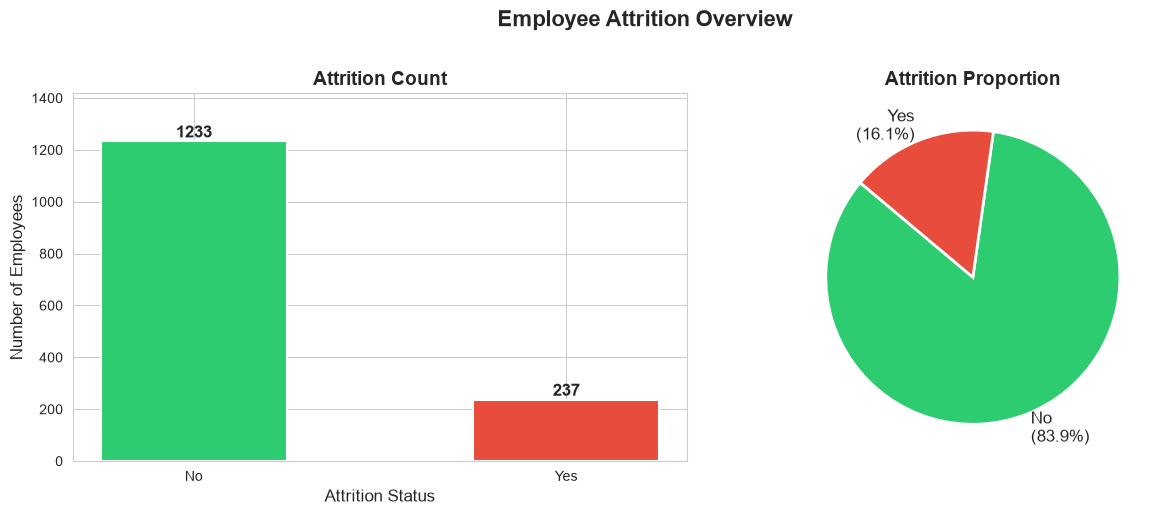

In [11]:
attrition_counts = df_clean['Attrition'].value_counts()
attrition_pct    = df_clean['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Employee Attrition Overview', fontsize=16, fontweight='bold', y=1.02)

# Bar chart
colors = [ATTRITION_COLORS[k] for k in attrition_counts.index]
bars = axes[0].bar(attrition_counts.index, attrition_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Attrition Count', fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Number of Employees')
axes[0].set_ylim(0, attrition_counts.max() * 1.15)
for bar, val in zip(bars, attrition_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 15, str(val),
                 ha='center', fontweight='bold', fontsize=12)

# Pie chart
wedge_colors = [ATTRITION_COLORS[k] for k in attrition_counts.index]
axes[1].pie(attrition_counts.values,
            labels=[f'{k}\n({v:.1f}%)' for k, v in zip(attrition_counts.index, attrition_pct)],
            colors=wedge_colors,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Attrition Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/plot1_attrition_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation — Plot 1

The dataset exhibits **class imbalance**: approximately **83.9%** of employees stayed (`No`) while only **16.1%** left (`Yes`). This 5:1 imbalance must be addressed during model training — techniques such as `class_weight='balanced'` or SMOTE oversampling will be considered in the modelling phase to prevent the classifier from being biased toward the majority class.

### Plot 2 — Department-wise Attrition Rate

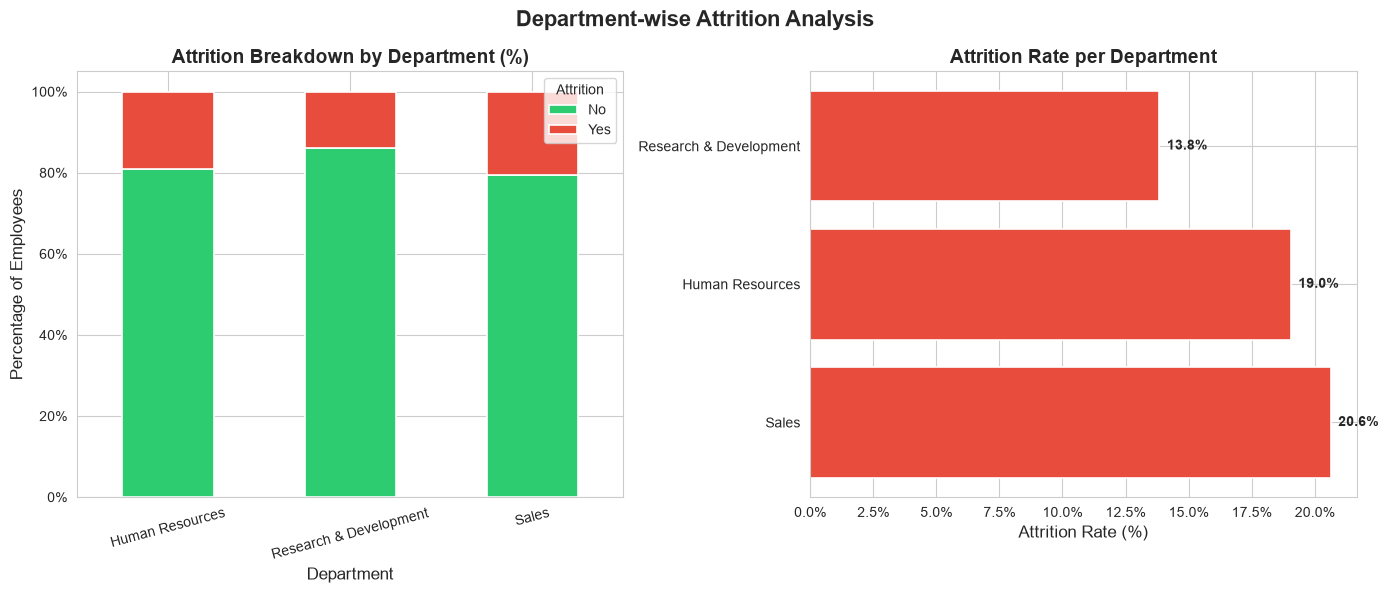

In [12]:
dept_attrition = (df_clean.groupby('Department')['Attrition']
                  .value_counts(normalize=True)
                  .unstack() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Department-wise Attrition Analysis', fontsize=16, fontweight='bold')

# Stacked bar
dept_attrition.plot(kind='bar', stacked=True,
                    color=[ATTRITION_COLORS['No'], ATTRITION_COLORS['Yes']],
                    ax=axes[0], edgecolor='white', linewidth=1.2, rot=15)
axes[0].set_title('Attrition Breakdown by Department (%)', fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Percentage of Employees')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Attrition', loc='upper right')

# Attrition rate only
dept_yes = dept_attrition['Yes'].sort_values(ascending=False)
bars = axes[1].barh(dept_yes.index, dept_yes.values,
                    color=ATTRITION_COLORS['Yes'],
                    edgecolor='white', linewidth=1.2)
axes[1].set_title('Attrition Rate per Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, dept_yes.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/plot2_department_attrition.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation — Plot 2

Attrition rates vary significantly by department. **Sales** shows the highest attrition rate, followed by **Human Resources**, while **Research & Development** has the lowest. This suggests that the nature of the work, pressure levels, and career growth opportunities differ meaningfully across departments — a key signal for HR to investigate department-specific retention strategies.

### Plot 3 — Monthly Income vs Attrition (Salary Analysis)

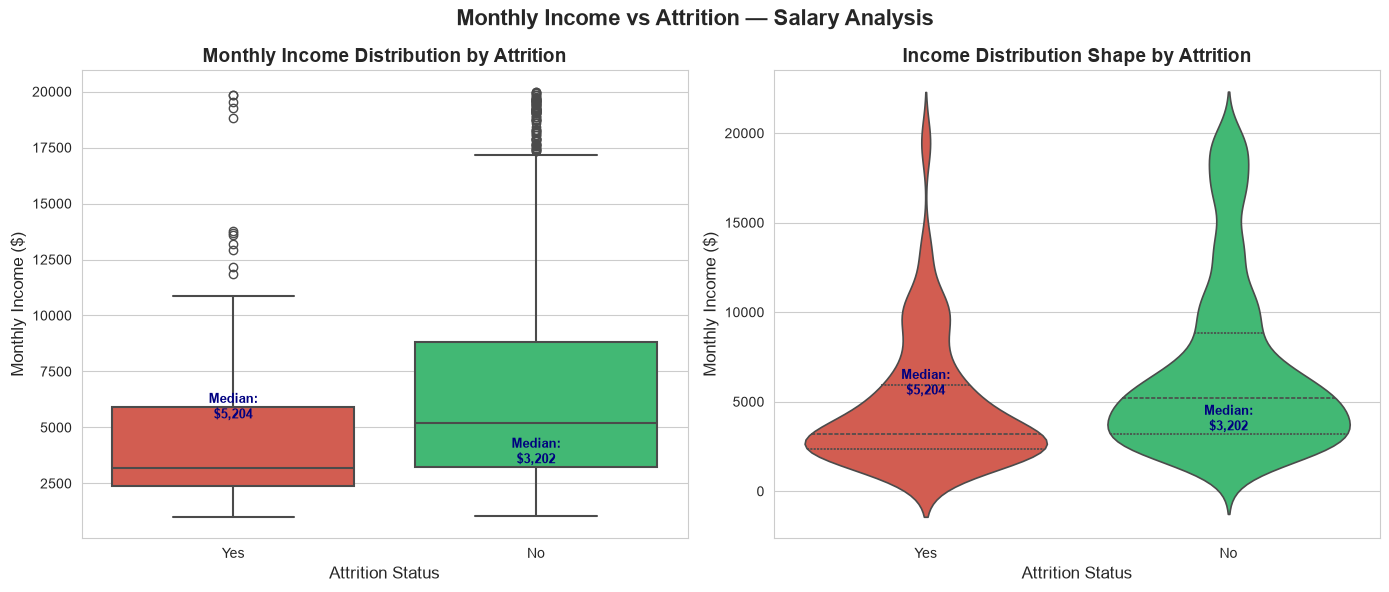

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Monthly Income vs Attrition — Salary Analysis', fontsize=16, fontweight='bold')

# Boxplot
sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome',
            palette=ATTRITION_COLORS, linewidth=1.5, ax=axes[0])
axes[0].set_title('Monthly Income Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Monthly Income ($)')

# Violin plot for richer distribution view
sns.violinplot(data=df_clean, x='Attrition', y='MonthlyIncome',
               palette=ATTRITION_COLORS, inner='quartile', linewidth=1.2, ax=axes[1])
axes[1].set_title('Income Distribution Shape by Attrition', fontweight='bold')
axes[1].set_xlabel('Attrition Status')
axes[1].set_ylabel('Monthly Income ($)')

# Annotate median values
for ax in axes:
    for i, group in enumerate(['No', 'Yes']):
        median_val = df_clean[df_clean['Attrition'] == group]['MonthlyIncome'].median()
        ax.text(i, median_val + 200, f'Median:\n${median_val:,.0f}',
                ha='center', fontsize=9, fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig('../images/plot3_salary_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation — Plot 3

Employees who left the organization (`Attrition = Yes`) have a **noticeably lower median monthly income** compared to those who stayed. The violin plot further reveals that the income distribution for departing employees is heavily concentrated at the lower end of the pay scale. This strongly indicates that **compensation is a significant driver of attrition** — employees feeling underpaid are more likely to seek opportunities elsewhere.

### Plot 4 — Overtime vs Attrition

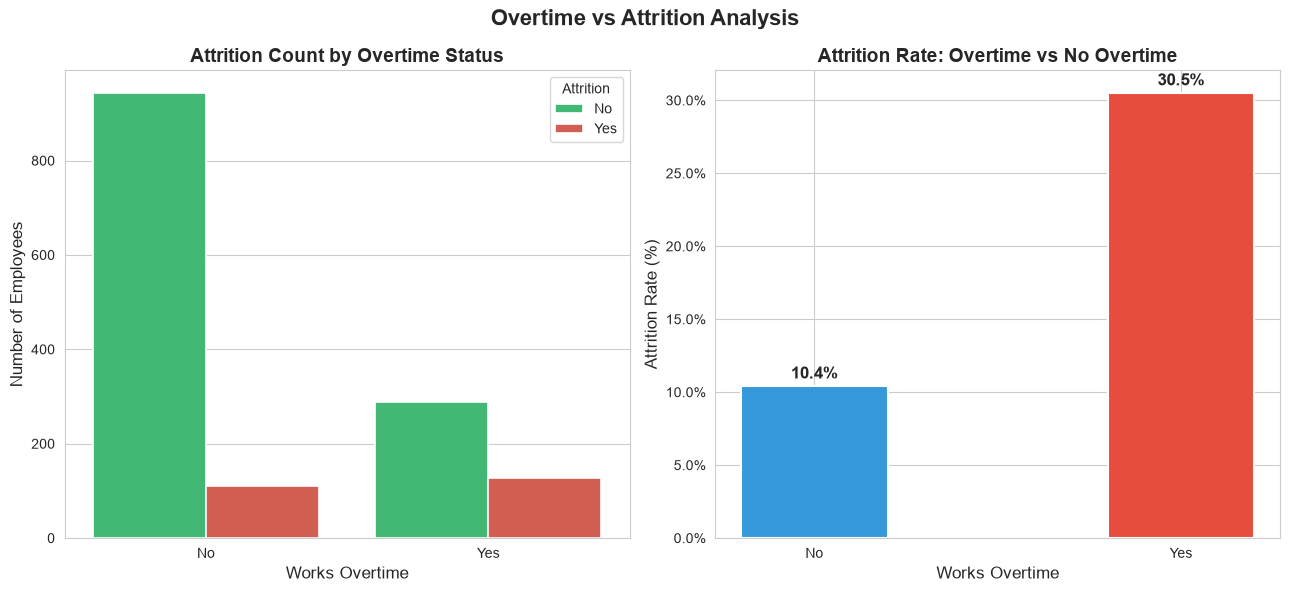

In [14]:
overtime_attrition = (df_clean.groupby(['OverTime', 'Attrition'])
                      .size()
                      .reset_index(name='Count'))

overtime_rate = (df_clean.groupby('OverTime')['Attrition']
                 .apply(lambda x: (x == 'Yes').mean() * 100)
                 .reset_index(name='AttritionRate'))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Overtime vs Attrition Analysis', fontsize=16, fontweight='bold')

# Grouped bar
sns.barplot(data=overtime_attrition, x='OverTime', y='Count',
            hue='Attrition', palette=ATTRITION_COLORS,
            edgecolor='white', linewidth=1.2, ax=axes[0])
axes[0].set_title('Attrition Count by Overtime Status', fontweight='bold')
axes[0].set_xlabel('Works Overtime')
axes[0].set_ylabel('Number of Employees')
axes[0].legend(title='Attrition')

# Attrition rate comparison
bars = axes[1].bar(overtime_rate['OverTime'], overtime_rate['AttritionRate'],
                   color=['#3498db', '#e74c3c'], edgecolor='white',
                   linewidth=1.5, width=0.4)
axes[1].set_title('Attrition Rate: Overtime vs No Overtime', fontweight='bold')
axes[1].set_xlabel('Works Overtime')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, overtime_rate['AttritionRate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../images/plot4_overtime_attrition.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation — Plot 4

Overtime is one of the **strongest individual predictors** of attrition. Employees working overtime have a significantly higher attrition rate compared to those who do not. This pattern points to burnout and work-life imbalance as critical push factors. Organizations should evaluate their overtime practices and consider flexible working arrangements or additional compensation to reduce this risk.

### Plot 5 — Job Satisfaction vs Attrition

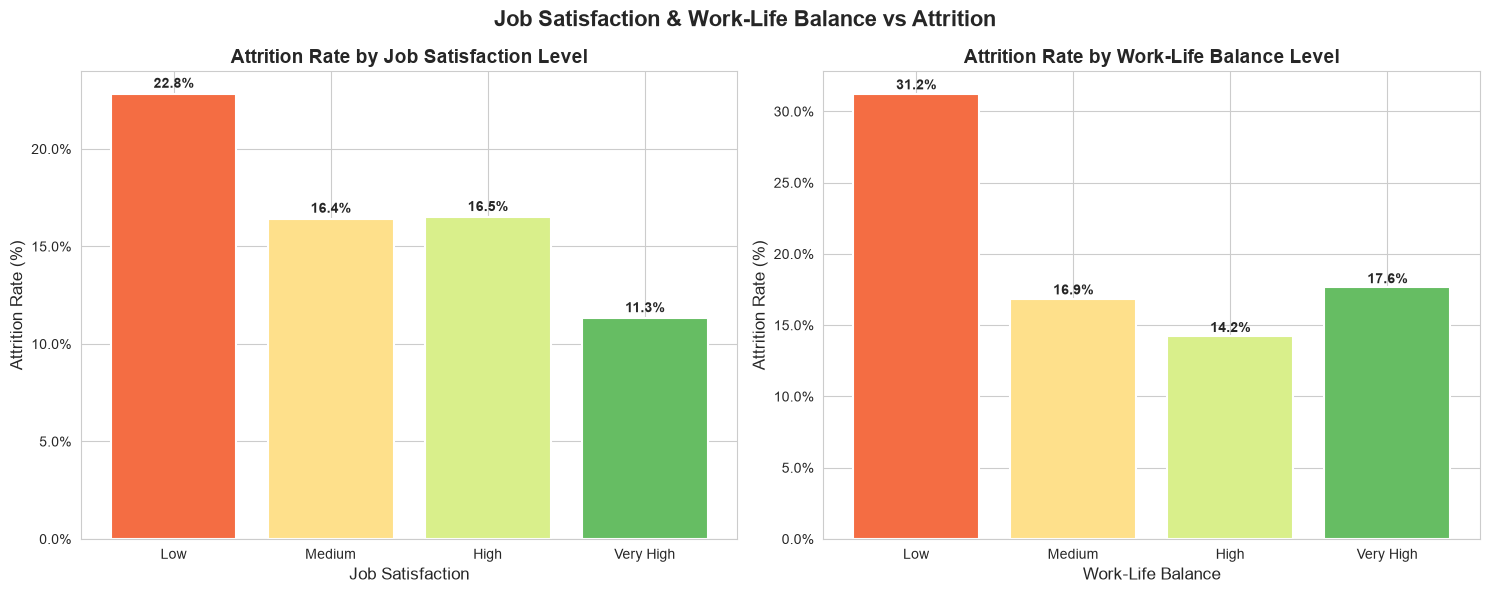

In [15]:
# Rating label maps
satisfaction_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df_plot = df_clean.copy()
df_plot['JobSatisfaction_Label'] = df_plot['JobSatisfaction'].map(satisfaction_labels)
df_plot['WorkLifeBalance_Label'] = df_plot['WorkLifeBalance'].map(satisfaction_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Job Satisfaction & Work-Life Balance vs Attrition', fontsize=16, fontweight='bold')

order = ['Low', 'Medium', 'High', 'Very High']

# Job Satisfaction
js_rate = (df_plot.groupby('JobSatisfaction_Label')['Attrition']
           .apply(lambda x: (x == 'Yes').mean() * 100))
js_rate = js_rate.reindex(order)
colors = sns.color_palette('RdYlGn', 4)
bars = axes[0].bar(js_rate.index, js_rate.values, color=colors,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Rate by Job Satisfaction Level', fontweight='bold')
axes[0].set_xlabel('Job Satisfaction')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, js_rate.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Work-Life Balance
wlb_rate = (df_plot.groupby('WorkLifeBalance_Label')['Attrition']
            .apply(lambda x: (x == 'Yes').mean() * 100))
wlb_rate = wlb_rate.reindex(order)
bars2 = axes[1].bar(wlb_rate.index, wlb_rate.values, color=colors,
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('Attrition Rate by Work-Life Balance Level', fontweight='bold')
axes[1].set_xlabel('Work-Life Balance')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, wlb_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/plot5_satisfaction_attrition.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation — Plot 5

Both Job Satisfaction and Work-Life Balance show a **clear inverse relationship** with attrition. Employees reporting `Low` satisfaction levels exhibit the highest attrition rates, while those reporting `Very High` satisfaction are far more likely to remain. This is a critical HR insight: **investing in employee satisfaction programs and flexible work policies can meaningfully reduce voluntary turnover.**

### Plot 6 — Cross-Feature Correlation Heatmap

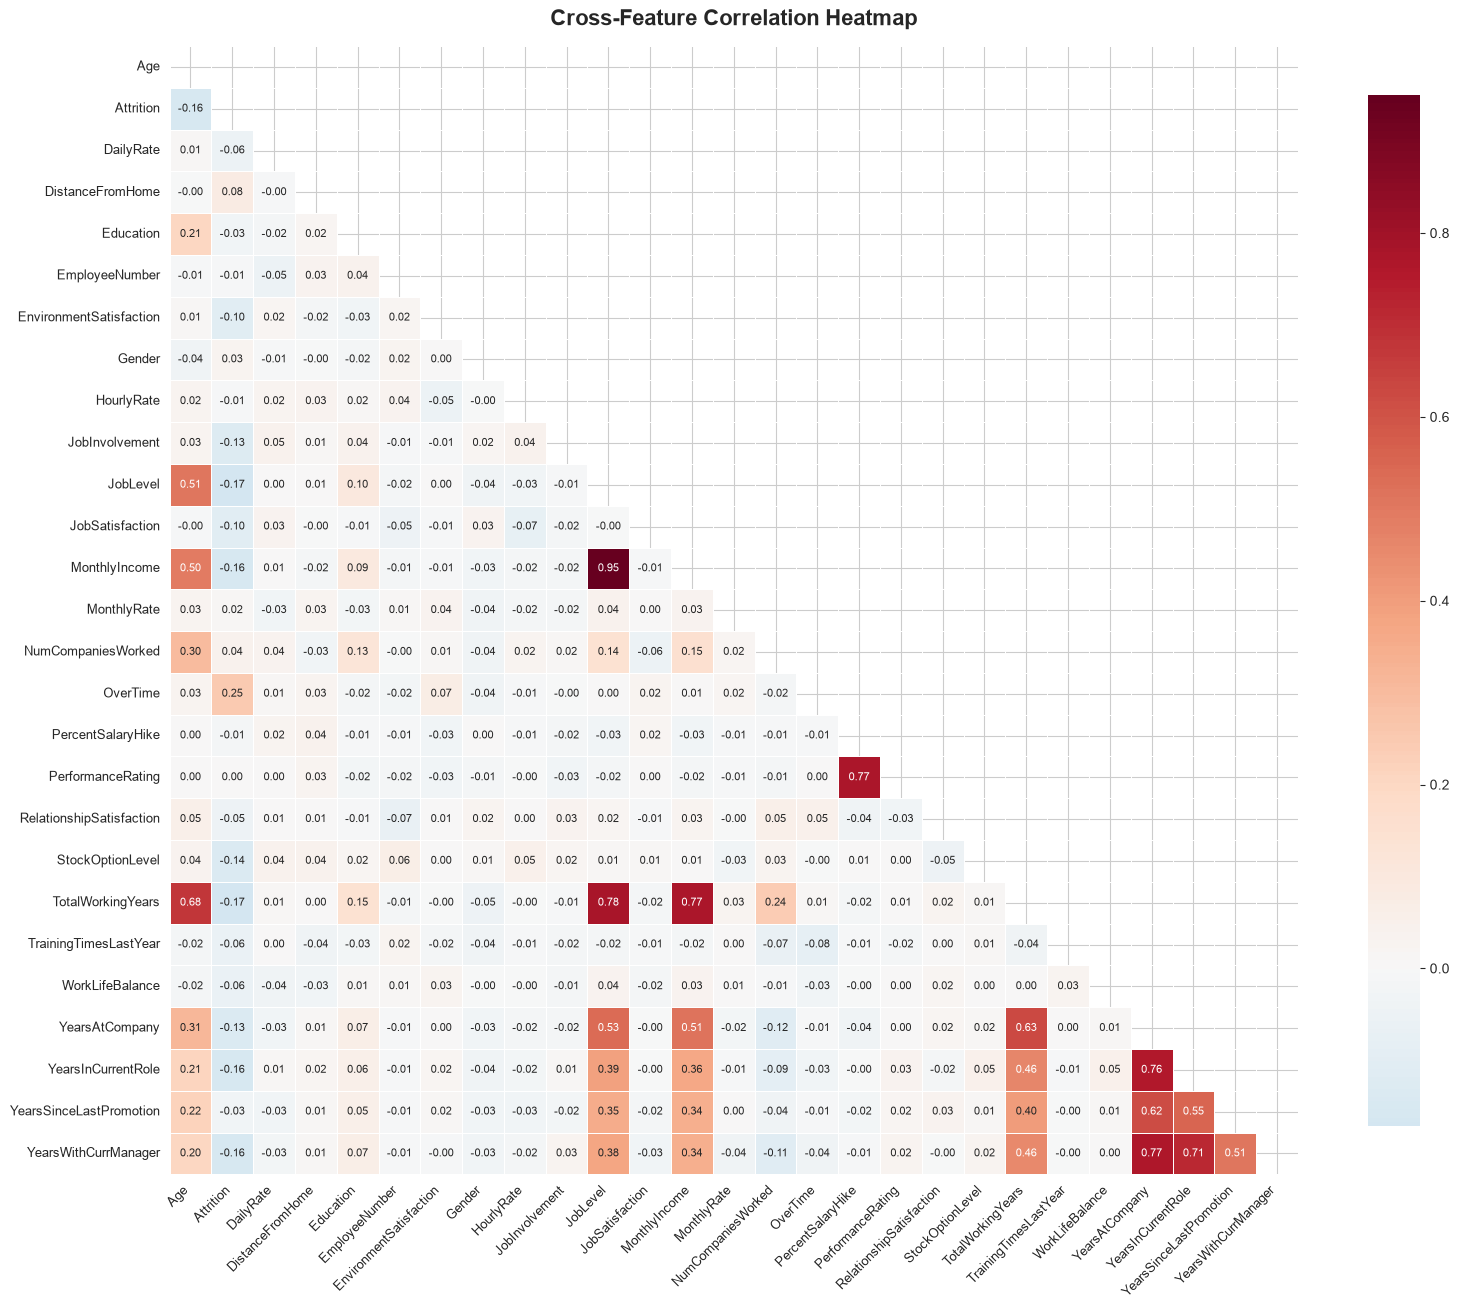

In [16]:
# Use the label-encoded version (before one-hot) for a cleaner heatmap
df_corr = df_clean.copy()
for col, mapping in binary_mappings.items():
    df_corr[col] = df_corr[col].map(mapping)

# Keep only numeric columns
df_corr_num = df_corr.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = df_corr_num.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title('Cross-Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../images/plot6_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [17]:
# Top features correlated with Attrition
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print('Top 10 features most correlated with Attrition:')
print(attrition_corr.head(10).to_string())

Top 10 features most correlated with Attrition:
OverTime                0.246118
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016


### Observation — Plot 6

The correlation heatmap reveals several important cross-feature relationships:

- **`OverTime`** shows the strongest positive correlation with `Attrition` — confirming the overtime analysis above.
- **`MonthlyIncome`**, **`JobLevel`**, and **`TotalWorkingYears`** are negatively correlated with attrition — more senior, higher-paid, experienced employees tend to stay.
- **`YearsAtCompany`**, **`YearsInCurrentRole`**, and **`YearsWithCurrManager`** are also negatively correlated — longer tenure means lower flight risk.
- Notable multicollinearity exists between `MonthlyIncome` and `JobLevel`, and between the various `Years*` columns — this will need to be managed during feature selection for the model.

---
## Executive Observations | Executive Observations — Business Insights Report

**Goal:** Translate mathematical trends and data plots into structured business narratives for HR teams.

**Deliverable:** Business Insights Report

### 🏢 Business Insights Report — Employee Attrition Analysis
**Prepared for:** HR Leadership & People Strategy Team

---

#### 1. Scale of the Problem

Of the 1,470 employees in our dataset, **237 (16.1%) have left the organization**. While this may appear to be a small proportion, losing 1 in every 6 employees represents a significant and recurring cost — including recruitment, onboarding, and productivity loss — that compounds over time.

---

#### 2. Where Is Attrition Happening?

Attrition is **not evenly distributed** across the organization. The **Sales department** exhibits the highest attrition rate, followed by **Human Resources**. Research & Development, despite being the largest department, maintains the lowest attrition rate.

> **Recommended Action:** HR should conduct targeted stay interviews and satisfaction surveys in the Sales department to identify department-specific pressure points.

---

#### 3. Compensation Is a Primary Driver

Employees who left the organization earned a **significantly lower median salary** than those who stayed. The data shows that attrition is concentrated among lower pay bands. This is a strong signal that compensation competitiveness is a core retention lever.

> **Recommended Action:** Conduct a market compensation benchmarking exercise, particularly for junior and mid-level roles in high-attrition departments.

---

#### 4. Overtime Is a Red Flag

Employees who regularly work overtime have a **dramatically higher attrition rate** than those who do not. Sustained overtime is a reliable indicator of burnout and dissatisfaction, and represents one of the most actionable signals for HR to monitor.

> **Recommended Action:** Flag employees with consistently high overtime hours for manager check-ins. Review team resourcing to determine whether overtime is structural (a staffing gap) or incidental.

---

#### 5. Satisfaction Levels Are Predictive

Both **Job Satisfaction** and **Work-Life Balance** scores show a clear, inverse relationship with attrition — the lower the score, the higher the likelihood of an employee leaving. Employees rating their satisfaction as `Low` are far more likely to resign than those rating it `High` or `Very High`.

> **Recommended Action:** Implement regular pulse surveys to track satisfaction in near real-time. Build an early-warning dashboard that flags employees whose scores drop below a defined threshold.

---

#### 6. Tenure and Seniority Are Stabilizers

More experienced employees — measured by `TotalWorkingYears`, `YearsAtCompany`, and `JobLevel` — are significantly less likely to leave. This suggests that attrition risk is **highest in the early years of employment**, making structured onboarding, mentorship, and clear career pathing critical for new hires.

> **Recommended Action:** Design a structured 90-day and 1-year retention programme for all new hires. Ensure job growth conversations happen within the first year.

---

#### Summary Table of Key Risk Factors

| Risk Factor | Attrition Signal | Priority |
|---|---|---|
| Works Overtime | Very High Attrition Rate | 🔴 Critical |
| Low Monthly Income | High Attrition Concentration | 🔴 Critical |
| Low Job Satisfaction | High Attrition Rate | 🔴 Critical |
| Sales Department | Highest Dept. Attrition | 🟠 High |
| Low Work-Life Balance | Elevated Attrition Rate | 🟠 High |
| New Employee (< 2 yrs) | Flight Risk Window | 🟡 Medium |
| Low Job Level | Higher Attrition Skew | 🟡 Medium |

---
